# 📊 AdventureWorks Operational KPI & SQL Analysis

Welcome to your self-serve analytics notebook! This notebook is connected directly to your local SQLite database (`adventure_works.db`) created by our ETL pipeline. 

Below, you will find pre-written queries and pandas code blocks to help you extract key performance indicators (KPIs) and visualize business insights instantly.

### 1. ⚙️ Connect to the Database and Import Libraries
Run the block below to import `sqlite3`, `pandas` for data manipulation, and plotting libraries (`matplotlib` and `seaborn`) to render interactive charts.

In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Connect to our database
conn = sqlite3.connect("adventure_works.db")
print("✅ Successfully connected to adventure_works.db!")

✅ Successfully connected to adventure_works.db!


### 2. 🏆 Top 10 Products by Gross Revenue
Let's write a SQL query to identify our highest revenue-generating products. We will join the `sales` fact table with the `products` dimension table, aggregate the total sales, and load the result into a Pandas DataFrame.

In [3]:
query_top_products = """
SELECT 
    p.ProductName,
    p.ModelName,
    SUM(s.OrderQuantity) as UnitsSold,
    ROUND(SUM(s.OrderQuantity * p.ProductPrice), 2) as GrossRevenue
FROM sales s
JOIN products p ON s.ProductKey = p.ProductKey
GROUP BY p.ProductKey
ORDER BY GrossRevenue DESC
LIMIT 10;
"""

df_top_products = pd.read_sql_query(query_top_products, conn)
df_top_products

,ProductName,ModelName,UnitsSold,GrossRevenue
0,"Mountain-200 Black, 46",Mountain-200,606,1241753.51
1,"Mountain-200 Black, 42",Mountain-200,602,1233557.12
2,"Mountain-200 Silver, 38",Mountain-200,586,1213851.89
3,"Mountain-200 Silver, 46",Mountain-200,571,1182780.59
4,"Mountain-200 Black, 38",Mountain-200,569,1165936.88
5,"Mountain-200 Silver, 42",Mountain-200,547,1133066.52
6,"Road-250 Black, 52",Road-250,316,689373.75
7,"Road-250 Red, 58",Road-250,303,661013.44
8,"Road-250 Black, 48",Road-250,294,641379.38
9,"Road-150 Red, 48",Road-150,179,640510.33


Let's visualize this top 10 products list using a horizontal bar chart!

In [ ]:
sns.barplot(
    x="GrossRevenue", 
    y="ProductName", 
    data=df_top_products, 
    hue="ProductName",
    palette="viridis",
    legend=False
)
plt.title("Top 10 Products by Gross Revenue", fontsize=16, fontweight='bold')
plt.xlabel("Revenue ($)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)
plt.tight_layout()
plt.show()

### 3. 📈 Monthly Revenue Trends
Tracking operational performance over time is crucial. Let's write a query to extract monthly sales revenue by parsing the standard `YYYY-MM-DD` date strings using SQLite's date modifiers.

In [4]:
query_monthly_sales = """
SELECT 
    strftime('%Y-%m', s.OrderDate) as MonthYear,
    ROUND(SUM(s.OrderQuantity * p.ProductPrice), 2) as MonthlyRevenue,
    SUM(s.OrderQuantity) as ItemsSold
FROM sales s
JOIN products p ON s.ProductKey = p.ProductKey
GROUP BY MonthYear
ORDER BY MonthYear;
"""

df_monthly_sales = pd.read_sql_query(query_monthly_sales, conn)
df_monthly_sales.head()

,MonthYear,MonthlyRevenue,ItemsSold
0,2020-01,585312.65,184
1,2020-02,532226.25,165
2,2020-03,643436.10,198
3,2020-04,653364.04,204
4,2020-05,659325.90,206


Let's plot the revenue growth trend over time!

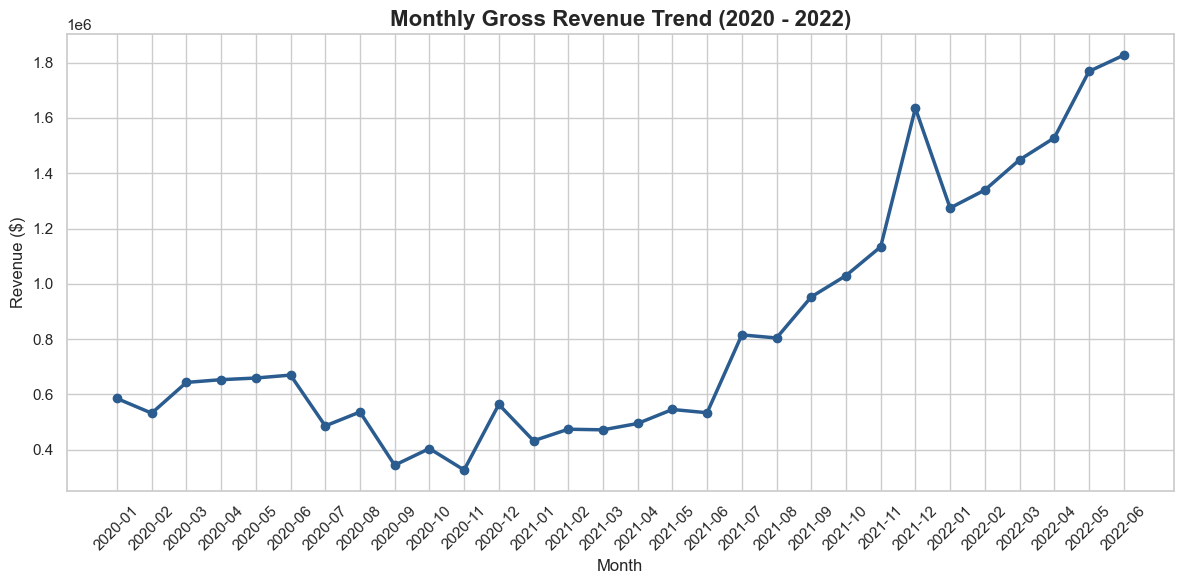

In [5]:
plt.plot(df_monthly_sales['MonthYear'], df_monthly_sales['MonthlyRevenue'], marker='o', linewidth=2.5, color='#2b5c8f')
plt.title("Monthly Gross Revenue Trend (2020 - 2022)", fontsize=16, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Revenue ($)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4. 🔄 Product Returns by Category
One key operational KPI is the Return Rate. Let's calculate the percentage of items returned compared to items sold for each Product Category.

In [6]:
query_returns = """
WITH SalesCTE AS (
    SELECT 
        cat.CategoryName,
        SUM(s.OrderQuantity) as TotalSold
    FROM sales s
    JOIN products p ON s.ProductKey = p.ProductKey
    JOIN subcategories sub ON p.ProductSubcategoryKey = sub.ProductSubcategoryKey
    JOIN categories cat ON sub.ProductCategoryKey = cat.ProductCategoryKey
    GROUP BY cat.CategoryName
),
ReturnsCTE AS (
    SELECT 
        cat.CategoryName,
        SUM(r.ReturnQuantity) as TotalReturned
    FROM returns r
    JOIN products p ON r.ProductKey = p.ProductKey
    JOIN subcategories sub ON p.ProductSubcategoryKey = sub.ProductSubcategoryKey
    JOIN categories cat ON sub.ProductCategoryKey = cat.ProductCategoryKey
    GROUP BY cat.CategoryName
)
SELECT 
    s.CategoryName,
    s.TotalSold,
    COALESCE(r.TotalReturned, 0) as TotalReturned,
    ROUND((CAST(COALESCE(r.TotalReturned, 0) as REAL) / s.TotalSold) * 100, 2) as ReturnRatePercent
FROM SalesCTE s
LEFT JOIN ReturnsCTE r ON s.CategoryName = r.CategoryName
ORDER BY ReturnRatePercent DESC;
"""

df_returns = pd.read_sql_query(query_returns, conn)
df_returns

,CategoryName,TotalSold,TotalReturned,ReturnRatePercent
0,Bikes,13929,429,3.08
1,Clothing,12436,269,2.16
2,Accessories,57809,1130,1.95


### 5. 🚪 Close Connection
Always remember to close your database connection when you're finished to release database locks.

In [7]:
conn.close()
print("🔒 Database connection closed safely!")

🔒 Database connection closed safely!
